In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Define functions to compute metrics for ensemble verification

In [2]:
# Nash-Sutcliffe Efficienty
def nse(observed, simulated):
    '''
    This is a normalized mean square error metric, similar to R2, higher is better [-inf, 1]
    This can be used to evaluate the ensemble mean against observation.
    observed: array of shape (T,), where T is number of time steps
    simulated: array of shape (T,),this is ensemble mean
    '''
    return 1 - np.sum((observed - simulated) ** 2) / np.sum((observed - np.mean(observed)) ** 2)

# Continuous Ranked Probability Score
def crps(observed, simulated):
    '''
    This is proper scoring rule for evaluating ensemble forecasts, lower is better [0, inf)
    observed: array of shape (T,), where T is number of time steps
    simulated: array of shape (T, M), where M is number of ensemble members
    '''
    T, M = simulated.shape
    # Sort the ensemble forecasts
    sorted_sim = np.sort(simulated, axis=1)
    # Compute the CRPS using the formula: CRPS = 1/M * sum(|x_i - y|) - 1/(2*M^2) * sum(|x_i - x_j|)
    crps_values = np.zeros(T)
    for t in range(T):
        x_i = sorted_sim[t, :]
        y = observed[t]
        crps_values[t] = np.mean(np.abs(x_i - y)) - 0.5 * np.mean(np.abs(x_i[:, None] - x_i[None, :]))
    return np.mean(crps_values)

# Reliability metrics
# calculate reliability metrics for ensemble forecasts
def ensemble_reliability(qobs, qsim, n_bins=10):
    """
    qobs : Observation, array of shape (T,)
    qsim : Ensemble simulations, array of shape (T, M)
    n_bins : Number of bins for reliability (default=10)
    
    Returns:
    obs_rank : Rank of observation within ensemble (0 to M) of shape (T,)
    obs_cdf : Observed cumulative probability (starts at 0), array of shape (n_bins+1,)
    unif_cdf : Uniform cumulative probability (starts at 0), array of shape (n_bins+1,)
    ri : Reliability index (mean absolute deviation betn observed and uniform CDF) (scalar)
    """
    qobs = np.asarray(qobs)
    qsim = np.asarray(qsim)
    M = qsim.shape[1]
    
    # Rank of observation within ensemble (0 to M)
    obs_rank = np.sum(qsim < qobs[:, None], axis=1)
    
    # Probability integral transform (PIT) values, cdf of qsim at qobs
    pit = np.sum(qsim <= qobs[:, None], axis=1) / M
    
    # Observed and uniform CDFs (with 0 prepended)
    hist, _ = np.histogram(pit, bins=n_bins, range=(0, 1))
    obs_cdf = np.concatenate([[0], np.cumsum(hist) / len(pit)])
    unif_cdf = np.concatenate([[0], np.arange(1, n_bins + 1) / n_bins])
    
    # Reliability index, mean absolute deviation from uniform distribution
    ri = np.mean(np.abs(obs_cdf - unif_cdf))
    
    return obs_rank, obs_cdf, unif_cdf, ri

## Read data

In [58]:
# read data
df = pd.read_csv('data/site_1.csv', parse_dates=['date'])
print(f'Total rows: {len(df)}, Total columns: {len(df.columns)}')
# visualize top 5 rows and first 5 columns
print(df.iloc[:5, :5])

Total rows: 366, Total columns: 102
        date    qobs  qsim_1  qsim_2  qsim_3
0 1980-01-01  0.2148   0.222   0.156   0.261
1 1980-01-02  0.2059   0.241   0.213   0.246
2 1980-01-03  0.2014   0.237   0.214   0.241
3 1980-01-04  0.2059   0.231   0.166   0.260
4 1980-01-05  0.2104   0.236   0.122   0.302


## Time-series plot of observation and ensemble forecasts

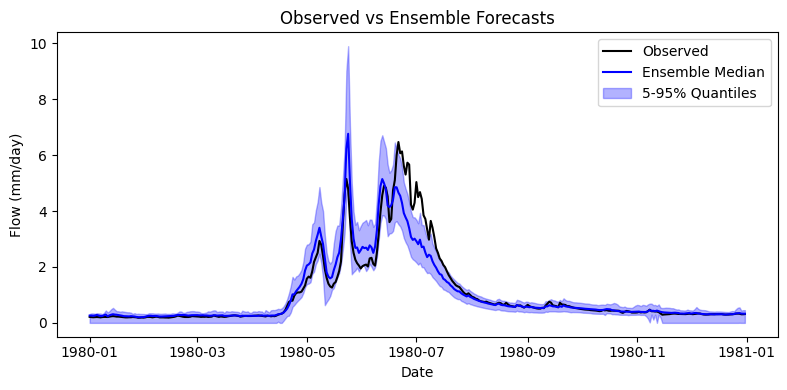

In [74]:
# make a time series plot of observed and simulated ensemble forecasts
# show ensemble median and 5-95% quantiles as shaded area
# compute ensemble median and quantiles
ens_col = df.columns[df.columns.str.startswith('qsim_')]
df['ensemble_median'] = df[ens_col].median(axis=1)
df['ensemble_q5'] = df[ens_col].quantile(0.05, axis=1)
df['ensemble_q95'] = df[ens_col].quantile(0.95, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(df['date'], df['qobs'], label='Observed', color='black')
plt.plot(df['date'], df['ensemble_median'], label='Ensemble Median', color='blue')
plt.fill_between(df['date'], df['ensemble_q5'], df['ensemble_q95'], color='blue', alpha=0.3, label='5-95% Quantiles')
plt.xlabel('Date')
plt.ylabel('Flow (mm/day)')
plt.title('Observed vs Ensemble Forecasts')
plt.legend()
plt.tight_layout()
plt.show()

## Reliability diagrams: a) probability plot b) deviation plot c) rank histogram

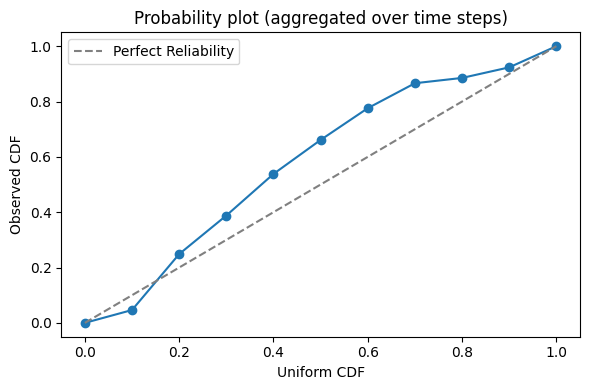

In [78]:
# a) Probability plot: plot observed cumulative probability vs uniform cumulative probability
obs_rank, obs_cdf, unif_cdf, ri = ensemble_reliability(df['qobs'], df[ens_col].values, n_bins=10)
plt.figure(figsize=(6, 4))
plt.plot(unif_cdf, obs_cdf, marker='o')
plt.plot([0, 1], [0, 1], '--', color='grey', label='Perfect Reliability')
plt.xlabel('Uniform CDF')
plt.ylabel('Observed CDF')
plt.title('Probability plot (aggregated over time steps)')
plt.legend()
plt.tight_layout()
plt.show()

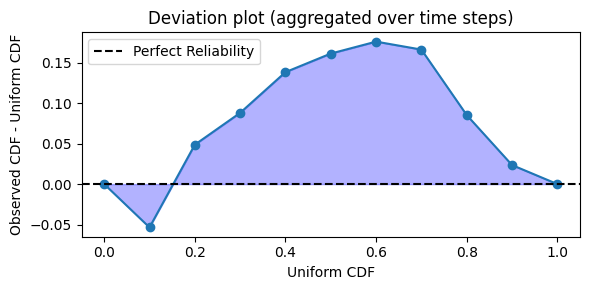

In [79]:
# b) Deviation plot: plot deviation of observed CDF from uniform CDF
plt.figure(figsize=(6, 3))
plt.plot(unif_cdf, obs_cdf - unif_cdf, marker='o')
plt.axhline(0, color='k', linestyle='--', label='Perfect Reliability')
plt.fill_between(unif_cdf, obs_cdf - unif_cdf, color = 'blue', alpha=0.3)
plt.xlabel('Uniform CDF')
plt.ylabel('Observed CDF - Uniform CDF')
plt.title('Deviation plot (aggregated over time steps)')
plt.legend()
plt.tight_layout()
plt.show()

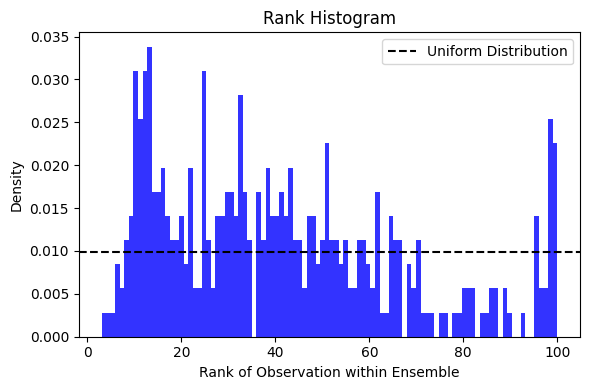

In [71]:
# c) Rank histogram: plot histogram of rank of observation within ensemble
M = len(ens_col) # number of ensemble members
plt.figure(figsize=(6, 4))
plt.hist(obs_rank, bins=M, density=True, alpha=0.8, color='blue')
plt.axhline(1 / (M + 1), color='k', linestyle='--', label='Uniform Distribution')
plt.xlabel('Rank of Observation within Ensemble')
plt.ylabel('Density')
plt.title('Rank Histogram')
plt.legend()
plt.tight_layout()
plt.show()

## Report metrics: NSE, CRPS, RI

In [47]:
# Report metrics: NSE, CRPS, RI
nse_value = nse(df['qobs'], df['ensemble_median'])
crps_value = crps(df['qobs'], df[ens_col].values)
ri_value = ri

report_df = pd.DataFrame({'NSE': [nse_value], 'CRPS': [crps_value], 'RI': [ri_value]})
print(report_df)

        NSE     CRPS        RI
0 -0.301306  0.00953  0.361638
